# Social Defeat Dopamine Analysis

DA data

In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(PROJECT_ROOT)

from trial_class import *
from experiment_class import Experiment
from bouts_extension import *
from sd_extension import *

In [2]:
nac_experiment_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Defeat\nac"
nac_csv_base_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Defeat\nac_csvs"
nac_color = '#15616F'

mpfc_experiment_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Defeat\mpfc"
mpfc_csv_base_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Defeat\mpfc_csvs"
mpfc_color = '#FFAF00'

# experiment_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Defeat\all_mice"
# csv_base_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Defeat\all_mice_csvs"



In [3]:
bout_definitions = [
    {'prefix': 'bully', 'introduced': 'Subject_Introduced', 'removed': 'Subject_Removed'}
]

In [4]:
# groups csv + experiment data into one variable
nac_exp = Experiment(nac_experiment_path, nac_csv_base_path)

mpfc_exp = Experiment(mpfc_experiment_path, mpfc_csv_base_path)

# # batch process the data, removing the specified time segments for subjects
# nac_exp.batch_process_exponential()
# mpfc_exp.batch_process_exponential()

nac_exp.default_batch_process()
mpfc_exp.default_batch_process()

Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Defeat\nac\n5-240916-092748\Notes.txt
read from t=0s to t=868.05s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Defeat\nac\n7-240916-113157\Notes.txt
read from t=0s to t=862.35s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Defeat\nac\nn1-250223-100216\Notes.txt
read from t=0s to t=866.05s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Defeat\nac\nn2-250223-102714\Notes.txt
read from t=0s to t=861.85s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Defeat\nac\nn3-250223-105155\Notes.txt
read from t=0s to t=864.35s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Defeat\nac\nn4-250223-111644\Notes.txt
read from t=0s to t=861.25s


### Peak standard z-score

In [86]:
nac_exp.group_extract_manual_annotations(bout_definitions=bout_definitions, first_only = False)

mpfc_exp.group_extract_manual_annotations(bout_definitions=bout_definitions, first_only = False)

# total_avg_bout_duration = metadata_df["Average Bout Duration"].mean()
# print(f"Total Average Bout Duration: {total_avg_bout_duration:.4f}")
# Proceed with DA metric computation after all files are processed
nac_exp.compute_all_da_metrics(use_max_length=True,
                                  max_bout_duration=9, #otal_avg_bout_duration
                                  mode='standard')

mpfc_exp.compute_all_da_metrics(use_max_length=True,
                                  max_bout_duration=9, #otal_avg_bout_duration
                                  mode='standard')

Processing behaviors for n5-240916-092748...
Processing behaviors for n7-240916-113157...
Processing behaviors for nn1-250223-100216...
Processing behaviors for nn2-250223-102714...
Processing behaviors for nn3-250223-105155...
Processing behaviors for nn4-250223-111644...
Processing behaviors for nn5-250223-114717...
Processing behaviors for nn6-250223-120921...
Processing behaviors for nn7-250223-123200...
Processing behaviors for nn8-250223-125722...
Processing behaviors for p1-240510-082326...
Processing behaviors for p2-240510-094249...
Processing behaviors for p3-240513-064912...
Processing behaviors for p5-240916-090016...
Processing behaviors for p6-240916-095652...
Processing behaviors for p7-240916-110418...
Processing behaviors for p8-240916-115836...
Processing behaviors for pp1-250223-093419...
Processing behaviors for pp2-250223-082553...
Processing behaviors for pp3-250223-084945...
Processing behaviors for pp4-250223-091227...
Processing behaviors for pp5-250223-132705.

In [87]:
nac_exp_da_dict = get_trial_dataframes(nac_exp)
mpfc_exp_da_dict = get_trial_dataframes(mpfc_exp)

In [88]:
desired_bouts = ['bully-1']

nac_da_metadata_df = create_da_metrics_dataframe(nac_exp_da_dict, behavior="Defeat", desired_bouts=desired_bouts)

mpfc_da_metadata_df = create_da_metrics_dataframe(mpfc_exp_da_dict, behavior="Defeat", desired_bouts=desired_bouts)

In [89]:
nac_da_metadata_df

,Subject,Bout,Behavior,AUC,Max Peak,Mean Z-score
0,n5,bully-1,Defeat,-0.111334,1.413116,0.057037
1,n7,bully-1,Defeat,-0.498187,0.458697,-0.229024
2,nn1,bully-1,Defeat,-2.812776,0.749918,-0.372093
3,nn2,bully-1,Defeat,0.179664,1.908858,0.026632
4,nn3,bully-1,Defeat,-0.137117,1.731925,-0.020105
5,nn4,bully-1,Defeat,-1.983693,1.225850,-0.233922
6,nn5,bully-1,Defeat,2.705023,1.978941,0.538744
7,nn6,bully-1,Defeat,1.391898,1.852559,0.464701
8,nn7,bully-1,Defeat,1.746800,2.047636,0.456329
9,nn8,bully-1,Defeat,0.831670,1.023052,0.219482


Comparing mice

Stats

In [90]:
import numpy as np
import pandas as pd
from scipy.stats import binomtest

def sign_test_against_zero(df, value_col='PeakVal', label='Region', bout_label=None, behavior_index=None, metric_name='AUC'):
    values = pd.to_numeric(df[value_col], errors='coerce').dropna()
    nonzero = values[values != 0]
    n_pos = int((nonzero > 0).sum())
    n_neg = int((nonzero < 0).sum())
    n_used = n_pos + n_neg

    if n_used == 0:
        return {
            'Region': label,
            'Bout': bout_label,
            'BehaviorIndex': behavior_index,
            'Metric': metric_name,
            'n_total': int(values.shape[0]),
            'n_used': 0,
            'n_pos': 0,
            'n_neg': 0,
            'median_value': np.nan,
            'p_value': np.nan,
        }

    p_value = binomtest(k=n_pos, n=n_used, p=0.5, alternative='two-sided').pvalue

    return {
        'Region': label,
        'Bout': bout_label,
        'BehaviorIndex': behavior_index,
        'Metric': metric_name,
        'n_total': int(values.shape[0]),
        'n_used': int(n_used),
        'n_pos': int(n_pos),
        'n_neg': int(n_neg),
        'median_value': float(np.median(values)),
        'p_value': float(p_value),
    }

def subject_level_subsequent_defeat_auc(exp_da_dict, region_label, selected_bout='bully-1', n_subsequent_behaviors=3):
    rows = []

    for subject_id, subj_df in exp_da_dict.items():
        if subj_df.empty:
            continue

        defeat_df = subj_df[(subj_df['Bout'] == selected_bout) & (subj_df['Behavior'] == 'Defeat')].copy()
        if defeat_df.empty:
            continue

        defeat_df.sort_values('Event_Start', inplace=True)
        defeat_df['BehaviorIndex'] = np.arange(1, len(defeat_df) + 1)
        defeat_df = defeat_df[defeat_df['BehaviorIndex'] <= n_subsequent_behaviors]

        for behavior_index, idx_df in defeat_df.groupby('BehaviorIndex', as_index=False):
            rows.append({
                'Subject': subject_id,
                'Bout': selected_bout,
                'BehaviorIndex': int(behavior_index),
                'PeakVal': float(pd.to_numeric(idx_df['AUC'], errors='coerce').mean()),
                'Region': region_label,
            })

    return pd.DataFrame(rows)

subject_level_df = pd.concat([
    subject_level_subsequent_defeat_auc(nac_exp_da_dict, 'NAc', selected_bout='bully-1', n_subsequent_behaviors=4),
    subject_level_subsequent_defeat_auc(mpfc_exp_da_dict, 'mPFC', selected_bout='bully-1', n_subsequent_behaviors=4),
], ignore_index=True)

results = []
for (region_label, bout_name, behavior_index), idx_df in subject_level_df.groupby(['Region', 'Bout', 'BehaviorIndex'], sort=True):
        results.append(
            sign_test_against_zero(
                idx_df,
                value_col='PeakVal',
                label=region_label,
                bout_label=bout_name,
                behavior_index=behavior_index,
                metric_name='AUC',
            )
        )

results = pd.DataFrame(results).sort_values(['Region', 'Bout', 'BehaviorIndex']).reset_index(drop=True)

results


,Region,Bout,BehaviorIndex,Metric,n_total,n_used,n_pos,n_neg,median_value,p_value
0,NAc,bully-1,1,AUC,10,10,8,2,1.465202,0.109375
1,NAc,bully-1,2,AUC,10,10,8,2,0.623557,0.109375
2,NAc,bully-1,3,AUC,10,10,6,4,0.214199,0.753906
3,NAc,bully-1,4,AUC,10,10,5,5,0.015639,1.000000
4,mPFC,bully-1,1,AUC,15,15,14,1,7.069850,0.000977
5,mPFC,bully-1,2,AUC,15,15,15,0,4.106324,0.000061
6,mPFC,bully-1,3,AUC,14,14,12,2,6.300306,0.012939
7,mPFC,bully-1,4,AUC,14,14,5,9,-0.592152,0.423950


In [91]:
# nac_exp_da_dict['n5']

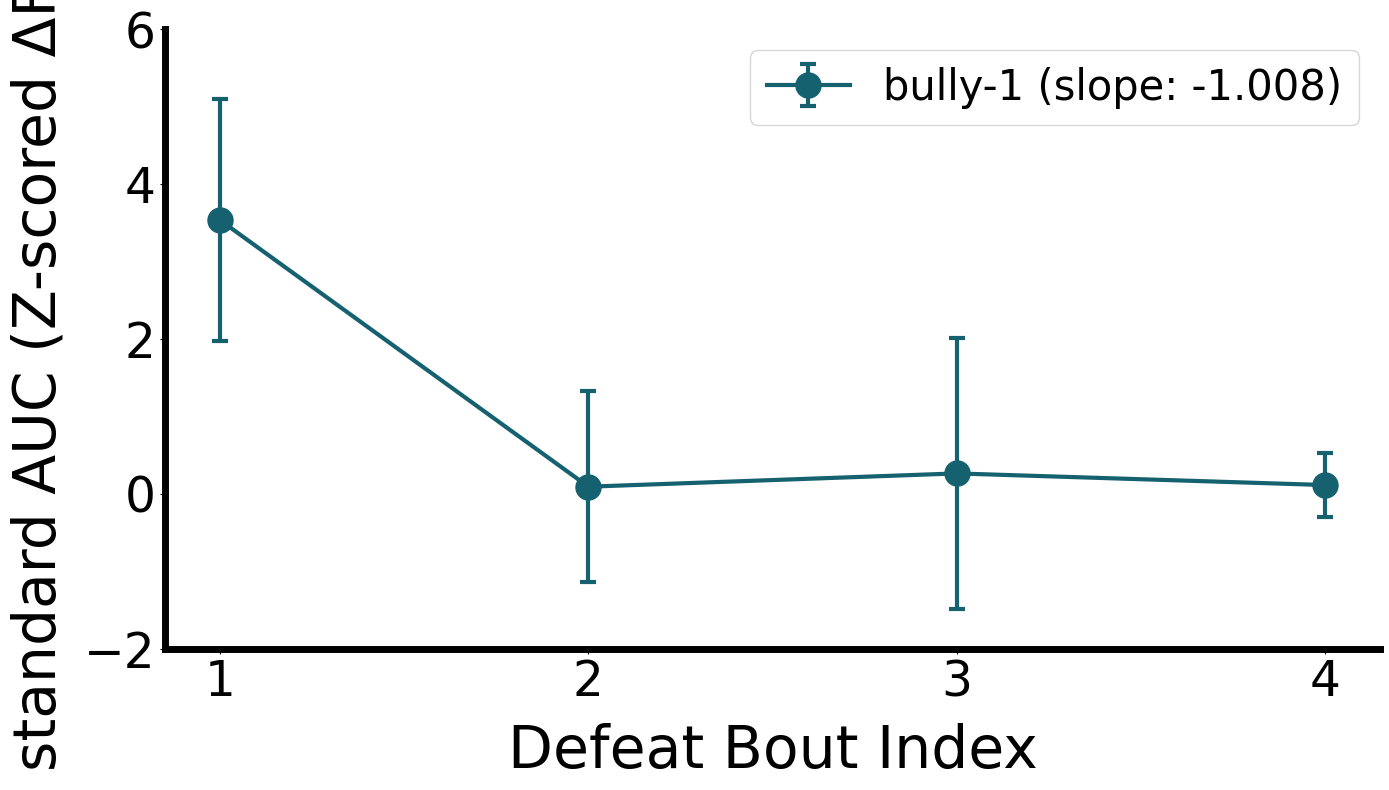


=== Computed Metric (SLOPE): ===
Bout: bully-1, slope = -1.008


,Bout,BehaviorIndex,SubjectCount,AvgPeak,StdPeak,SEM
0,bully-1,1,10,3.530608,4.941454,1.562625
1,bully-1,2,10,0.090557,3.900815,1.233546
2,bully-1,3,10,0.261989,5.531404,1.749183
3,bully-1,4,10,0.112004,1.321513,0.417899


In [95]:
plot_peak_for_subsequent_behaviors(nac_exp_da_dict, 
                                   selected_bouts=["bully-1"], 
                                   behavior="Defeat", 
                                   n_subsequent_behaviors=4,
                                   peak_col='AUC',
                                   xlabel="Defeat Bout Index",
                                    ylabel="standard AUC (Z-scored ΔF/F)",
                                    plot_title="",
                                    ylim = (-2, 6),
                                    custom_colors=nac_color,
                                    # save_path=None,
                                    figsize=(14,8),
                                    # save=True,
                                    save_path=r"C:\Users\alber\Downloads\NAc_defeat_AUC.png"
                                    )

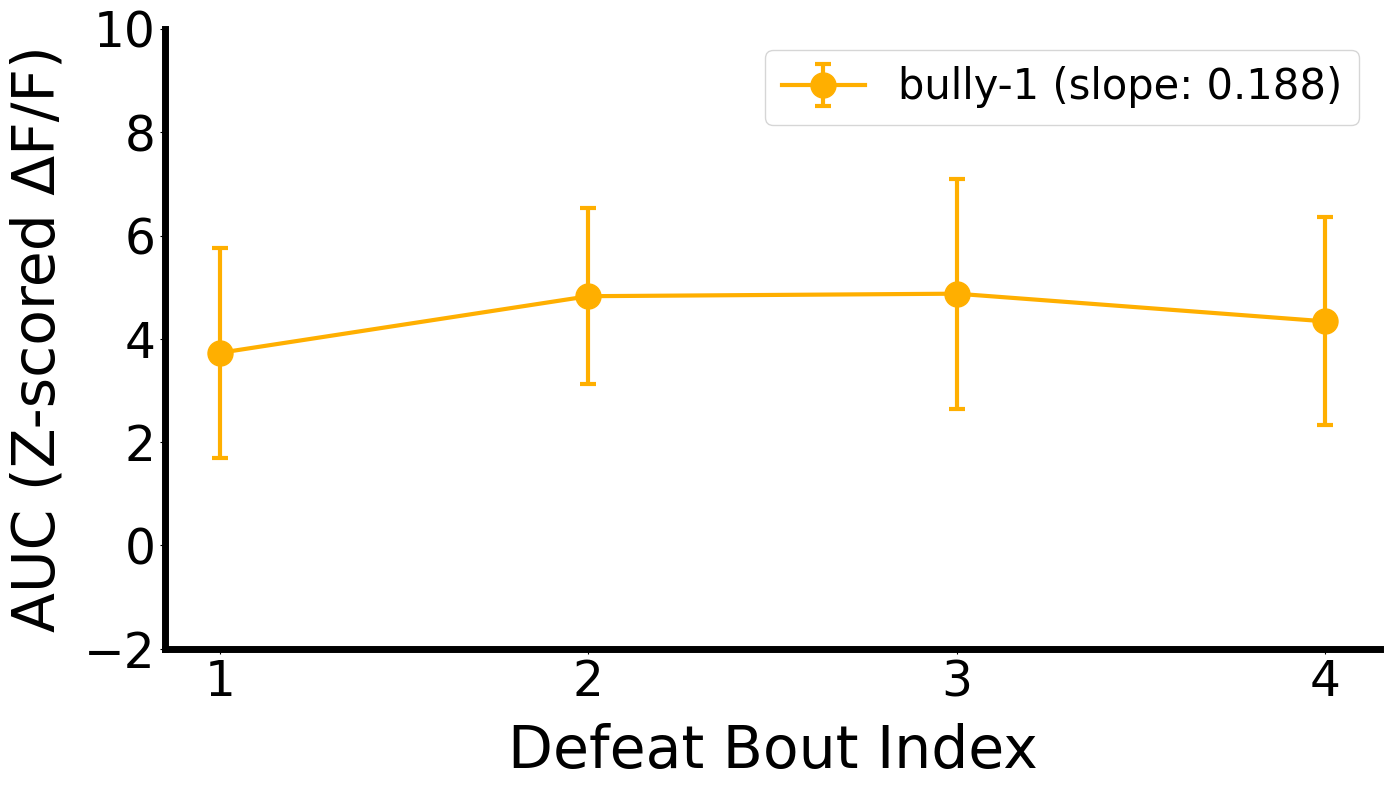


=== Computed Metric (SLOPE): ===
Bout: bully-1, slope = 0.188


,Bout,BehaviorIndex,SubjectCount,AvgPeak,StdPeak,SEM
0,bully-1,1,15,3.729456,7.876168,2.033618
1,bully-1,2,15,4.825233,6.593274,1.702376
2,bully-1,3,14,4.873806,8.332824,2.227041
3,bully-1,4,14,4.338597,7.548403,2.017396


In [81]:
plot_peak_for_subsequent_behaviors(mpfc_exp_da_dict, 
                                   selected_bouts=["bully-1"], 
                                   behavior="Defeat", 
                                   n_subsequent_behaviors=4,
                                   peak_col='AUC',
                                   xlabel="Defeat Bout Index",
                                    ylabel="AUC (Z-scored ΔF/F)",
                                    plot_title="",
                                    ylim = (-2, 10),
                                    custom_colors=mpfc_color,
                                    save=True,
                                    figsize=(14,8),
                                    save_path=r"C:\Users\alber\Downloads\mPFC_defeat_AUC.png"
                                    )

In [13]:
nac_exp.reset_all_behaviors()
nac_exp.group_extract_manual_annotations(bout_definitions=bout_definitions, first_only = False)


Processing behaviors for n5-240916-092748...
Processing behaviors for n7-240916-113157...
Processing behaviors for nn1-250223-100216...
Processing behaviors for nn2-250223-102714...
Processing behaviors for nn3-250223-105155...
Processing behaviors for nn4-250223-111644...
Processing behaviors for nn5-250223-114717...
Processing behaviors for nn6-250223-120921...
Processing behaviors for nn7-250223-123200...
Processing behaviors for nn8-250223-125722...


In [14]:
mpfc_exp.reset_all_behaviors()
mpfc_exp.group_extract_manual_annotations(bout_definitions=bout_definitions, first_only = False)


Processing behaviors for p1-240510-082326...
Processing behaviors for p2-240510-094249...
Processing behaviors for p3-240513-064912...
Processing behaviors for p5-240916-090016...
Processing behaviors for p6-240916-095652...
Processing behaviors for p7-240916-110418...
Processing behaviors for p8-240916-115836...
Processing behaviors for pp1-250223-093419...
Processing behaviors for pp2-250223-082553...
Processing behaviors for pp3-250223-084945...
Processing behaviors for pp4-250223-091227...
Processing behaviors for pp5-250223-132705...
Processing behaviors for pp6-250223-135048...
Processing behaviors for pp7-250223-141336...
Processing behaviors for pp8-250223-143545...


In [15]:
nac_exp.compute_all_event_induced_DA(pre_time=4, post_time=10)
mpfc_exp.compute_all_event_induced_DA(pre_time=4, post_time=10)

Computing event-induced DA for trial n5-240916-092748 ...
Computing event-induced DA for trial n7-240916-113157 ...
Computing event-induced DA for trial nn1-250223-100216 ...
Computing event-induced DA for trial nn2-250223-102714 ...
Computing event-induced DA for trial nn3-250223-105155 ...
Computing event-induced DA for trial nn4-250223-111644 ...
Computing event-induced DA for trial nn5-250223-114717 ...
Computing event-induced DA for trial nn6-250223-120921 ...
Computing event-induced DA for trial nn7-250223-123200 ...
Computing event-induced DA for trial nn8-250223-125722 ...
Computing event-induced DA for trial p1-240510-082326 ...
Computing event-induced DA for trial p2-240510-094249 ...
Computing event-induced DA for trial p3-240513-064912 ...
Computing event-induced DA for trial p5-240916-090016 ...
Computing event-induced DA for trial p6-240916-095652 ...
Computing event-induced DA for trial p7-240916-110418 ...
Computing event-induced DA for trial p8-240916-115836 ...
Comput

In [16]:
# experiment.trials['n7-240916-113157'].behaviors.head()

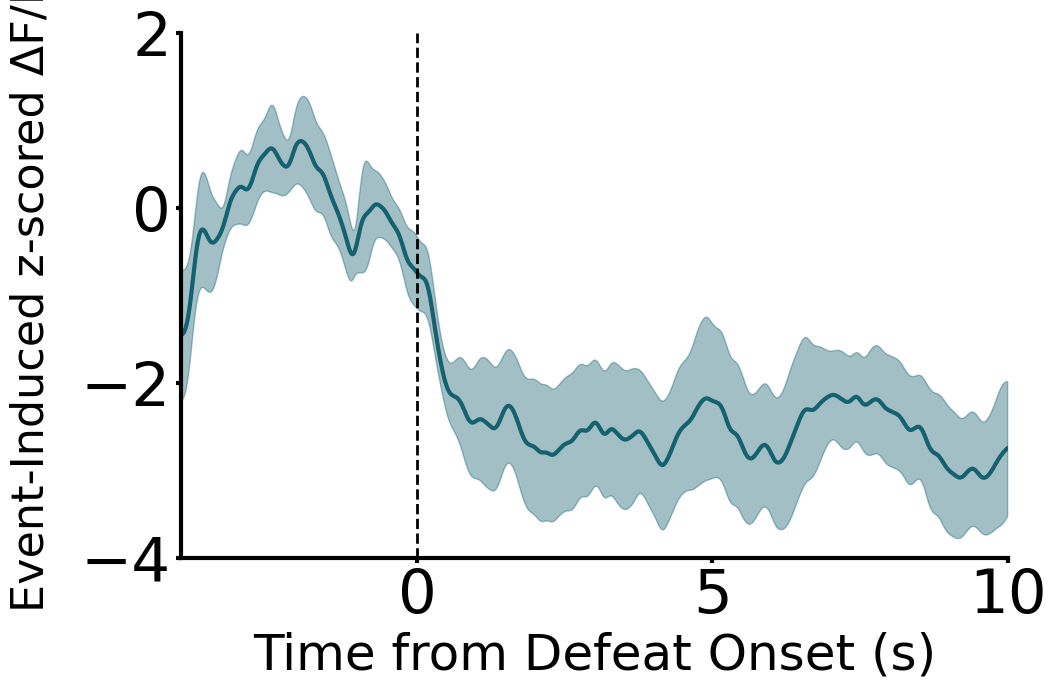

{'common_time_axis': array([-4.  , -3.99, -3.98, ...,  9.97,  9.98,  9.99]),
 'mean_trace': array([-1.45353803, -1.45171147, -1.44858213, ..., -2.76375239,
        -2.75741699, -2.75149785]),
 'sem_trace': array([0.74881756, 0.74560626, 0.7416878 , ..., 0.78205163, 0.77702906,
        0.77138539]),
 'n_trials': 10,
 'subject_ids': ['n5',
  'n7',
  'nn1',
  'nn2',
  'nn3',
  'nn4',
  'nn5',
  'nn6',
  'nn7',
  'nn8']}

In [17]:
plot_average_defeat_bout_psth(
    experiment=nac_exp,
    nth_defeat=1,
    save=False,
    # save_path= r"Social_Defeat\Social_Defeat_graphsplots/DefeatBout1_Average.png",
    y_min=-4, 
    y_max=2,
    brain_region=nac_color
)


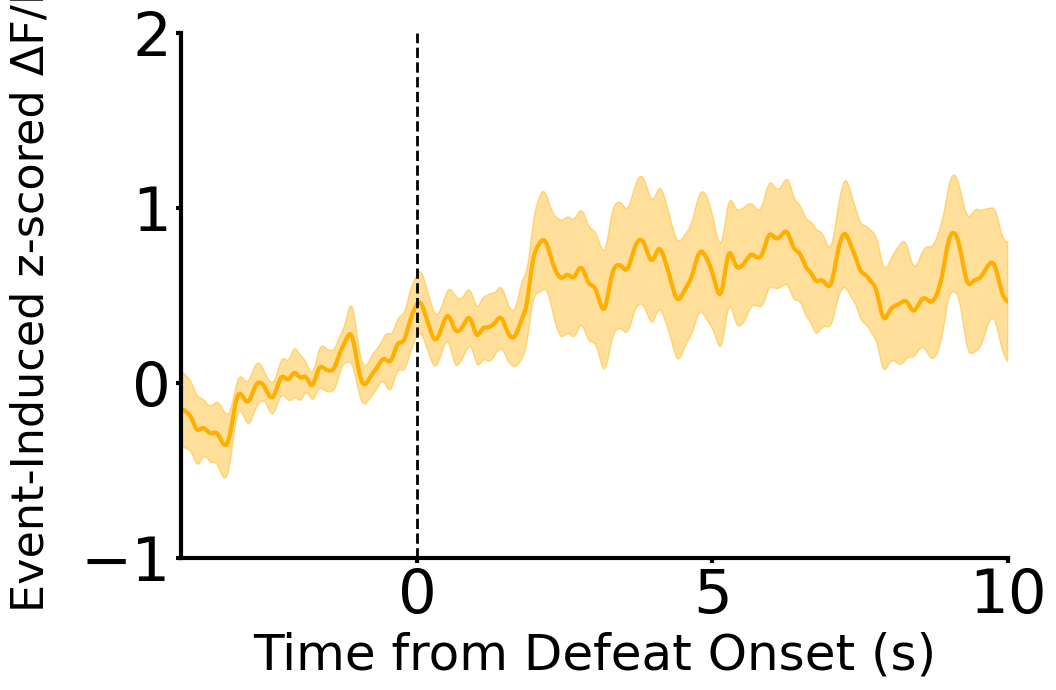

{'common_time_axis': array([-4.  , -3.99, -3.98, ...,  9.97,  9.98,  9.99]),
 'mean_trace': array([-0.15768932, -0.15435556, -0.15348411, ...,  0.47272285,
         0.47019106,  0.46839222]),
 'sem_trace': array([0.22425172, 0.22132281, 0.21892105, ..., 0.33747072, 0.33979328,
        0.3420749 ]),
 'n_trials': 15,
 'subject_ids': ['p1',
  'p2',
  'p3',
  'p5',
  'p6',
  'p7',
  'p8',
  'pp1',
  'pp2',
  'pp3',
  'pp4',
  'pp5',
  'pp6',
  'pp7',
  'pp8']}

In [18]:
plot_average_defeat_bout_psth(
    experiment=mpfc_exp,
    nth_defeat=1,
    save=False,
    # save_path= r"Social_Defeat\Social_Defeat_graphsplots/DefeatBout1_Average.png",
    y_min=-1, 
    y_max=2,
    brain_region=mpfc_color
)


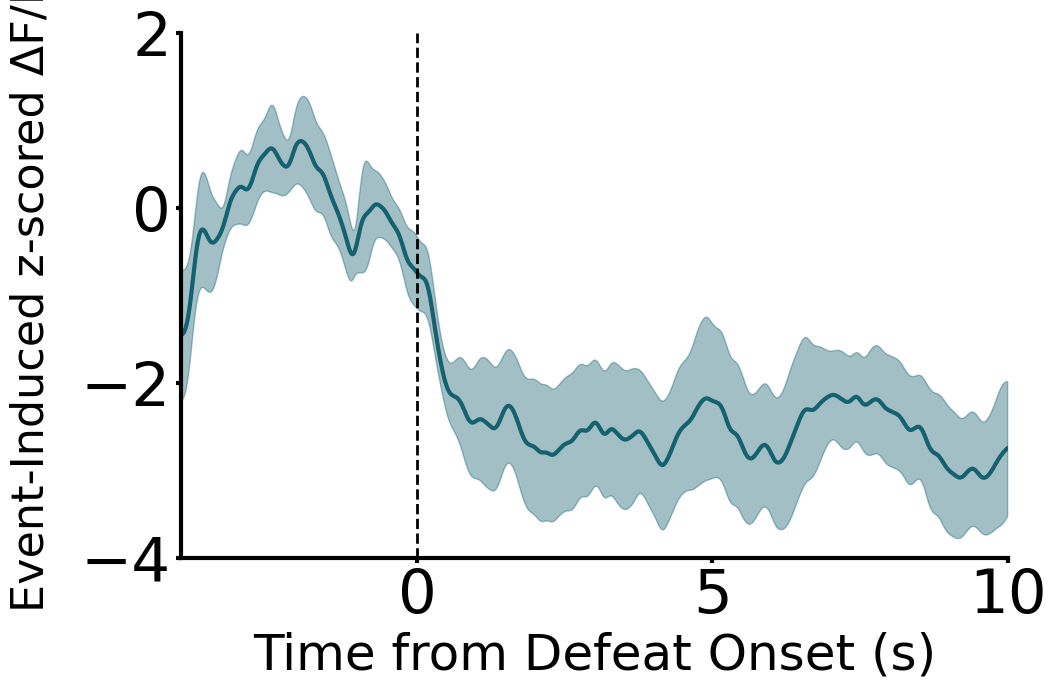

{'common_time_axis': array([-4.  , -3.99, -3.98, ...,  9.97,  9.98,  9.99]),
 'mean_trace': array([-1.45353803, -1.45171147, -1.44858213, ..., -2.76375239,
        -2.75741699, -2.75149785]),
 'sem_trace': array([0.74881756, 0.74560626, 0.7416878 , ..., 0.78205163, 0.77702906,
        0.77138539]),
 'n_trials': 10,
 'subject_ids': ['n5',
  'n7',
  'nn1',
  'nn2',
  'nn3',
  'nn4',
  'nn5',
  'nn6',
  'nn7',
  'nn8']}

In [19]:
plot_average_defeat_bout_psth(
    experiment=nac_exp,
    nth_defeat=1,
    save=False,
    # save_path= r"Social_Defeat\Social_Defeat_graphsplots/DefeatBout1_Average.png",
    y_min=-4, 
    y_max=2,
    brain_region=nac_color
)


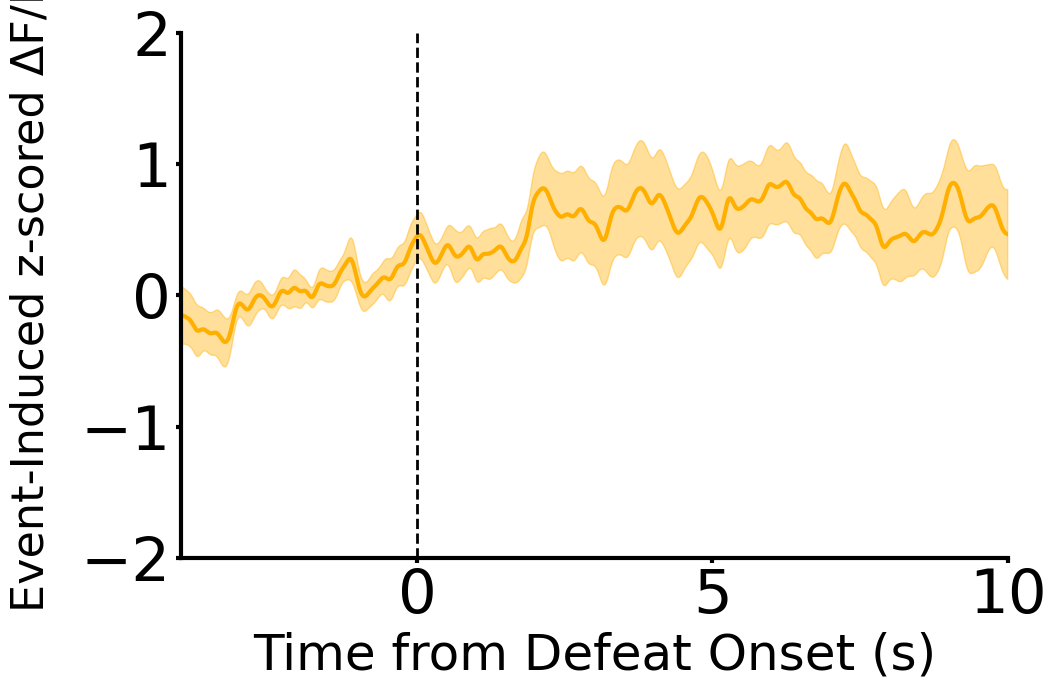

{'common_time_axis': array([-4.  , -3.99, -3.98, ...,  9.97,  9.98,  9.99]),
 'mean_trace': array([-0.15768932, -0.15435556, -0.15348411, ...,  0.47272285,
         0.47019106,  0.46839222]),
 'sem_trace': array([0.22425172, 0.22132281, 0.21892105, ..., 0.33747072, 0.33979328,
        0.3420749 ]),
 'n_trials': 15,
 'subject_ids': ['p1',
  'p2',
  'p3',
  'p5',
  'p6',
  'p7',
  'p8',
  'pp1',
  'pp2',
  'pp3',
  'pp4',
  'pp5',
  'pp6',
  'pp7',
  'pp8']}

In [20]:
plot_average_defeat_bout_psth(
    experiment=mpfc_exp,
    nth_defeat=1,
    save=False,
    # save_path= r"Social_Defeat\Social_Defeat_graphsplots/DefeatBout1_Average.png",
    y_min=-2, 
    y_max=2,
    brain_region=mpfc_color
)


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_all_defeat_bouts_psth(
    experiment,
    save_path=None,
    save=False,
    bin_size=100,
    y_min=-5,
    y_max=3,
    brain_region=None
):
    """
    Average & plot event‐induced DA for *all* Defeat bouts across all trials.

    Parameters
    ----------
    experiment : Experiment
        Your experiment object, with .trials each having a .behaviors DataFrame.
    save_path : str or None
        Where to save the figure (including filename). Required if save=True.
    save : bool
        If True, saves the figure to disk.
    bin_size : int
        Downsampling factor (passes through experiment.downsample_data if available).
    y_min, y_max : float
        y‐axis limits.
    brain_region : str
        Hex color for the trace. Defaults to mPFC‐gold if None.
    """
    trace_color = brain_region if brain_region is not None else "#FFAF00"
    all_traces = []
    missing = []

    # 1) collect every Defeat bout trace
    for trial in experiment.trials.values():
        if getattr(trial, "behaviors", None) is None or trial.behaviors.empty:
            missing.append(trial.subject_name)
            continue

        df_def = trial.behaviors[trial.behaviors["Behavior"] == "Defeat"]
        if df_def.empty:
            missing.append(trial.subject_name)
            continue

        # for each defeat event in this trial
        for _, row in df_def.iterrows():
            tz = row.get("Relative_Time_Axis", None)
            tzs = row.get("Relative_Zscore", None)
            if tz is None or tzs is None:
                continue
            all_traces.append(np.array(tzs))

    if missing:
        print("Skipped (no defeat bouts):", ", ".join(set(missing)))

    if not all_traces:
        print("No defeat‐bout traces found.")
        return None

    # 2) assume all Relative_Time_Axis are the same across events
    time_axis = np.array(df_def.iloc[0]["Relative_Time_Axis"])
    stack = np.vstack(all_traces)
    mean_trace = stack.mean(axis=0)
    sem_trace  = stack.std(axis=0) / np.sqrt(stack.shape[0])

    # 3) optional downsample
    if hasattr(experiment, "downsample_data"):
        mean_trace, time_ds = experiment.downsample_data(mean_trace, time_axis, bin_size)
        sem_trace, _    = experiment.downsample_data(sem_trace,  time_axis, bin_size)
    else:
        time_ds = time_axis

    # 4) plot
    plt.figure(figsize=(14, 7))
    plt.plot(time_ds, mean_trace, color=trace_color, lw=3, label="Mean Defeat DA")
    plt.fill_between(time_ds,
                     mean_trace - sem_trace,
                     mean_trace + sem_trace,
                     color=trace_color, alpha=0.4,
                     label="SEM")
    plt.axvline(0, color="k", linestyle="--", lw=2)

    plt.xlabel("Time from Defeat Onset (s)", fontsize=24)
    plt.ylabel("Event‐Induced z‐scored ΔF/F", fontsize=24)
    plt.xlim(time_ds.min(), time_ds.max())
    plt.ylim(y_min, y_max)

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=16, width=2)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.legend(fontsize=16)

    plt.tight_layout()

    if save:
        if save_path is None:
            raise ValueError("save_path must be set if save=True")
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)

    plt.show()

    return {
        "time_axis": time_ds,
        "mean_trace": mean_trace,
        "sem_trace": sem_trace,
        "n_events": stack.shape[0]
    }


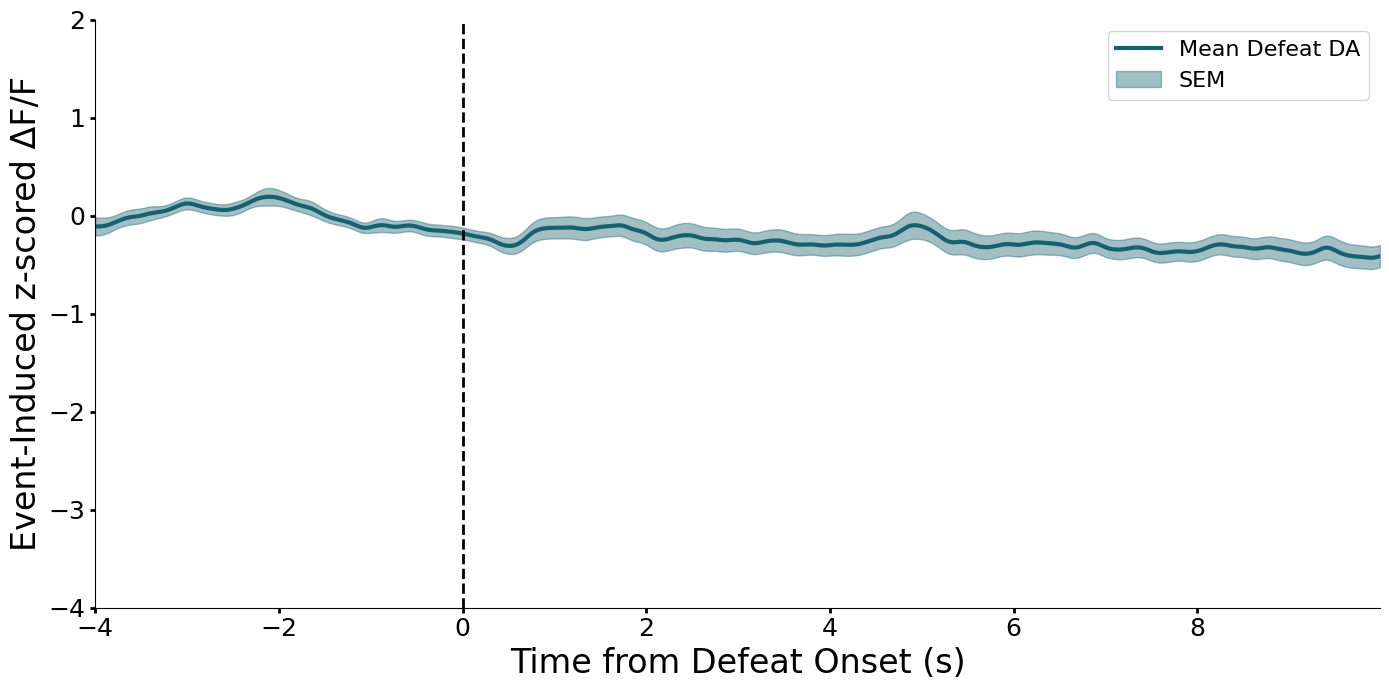

128 total defeat bouts averaged


In [22]:
res = plot_all_defeat_bouts_psth(
    experiment=nac_exp,
    save=False,
    y_min=-4, 
    y_max=2,
    brain_region=nac_color
)
print(res["n_events"], "total defeat bouts averaged")


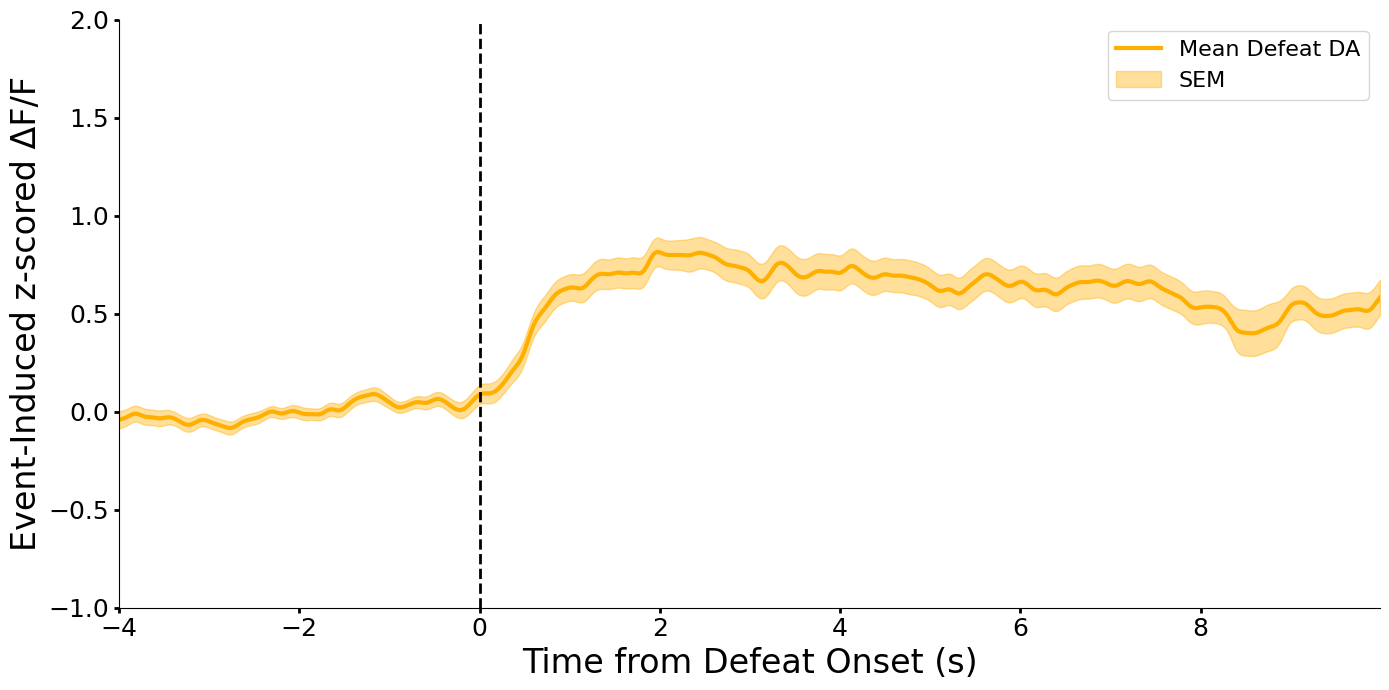

164 total defeat bouts averaged


In [23]:
res = plot_all_defeat_bouts_psth(
    experiment=mpfc_exp,
    save=False,
    y_min=-1, 
    y_max=2,
    brain_region=mpfc_color
)
print(res["n_events"], "total defeat bouts averaged")
